# Adidas Business Analytics Project
**Student:** Siddhesh Kamble | **Roll No.:** T009 | **Class:** TY B.Sc. IT

Beginner-friendly notebook with separate Markdown and code blocks. Keep this notebook in the project root beside the `Dataset` folder. Run cells from top to bottom.


## 0. Install Required Libraries

In [1]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels pulp


Note: you may need to restart the kernel to use updated packages.


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load Dataset

In [3]:
df = pd.read_csv("Adidas_Business_Analytics_Master_Dataset.csv")
print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())


Dataset loaded successfully!
Rows: 9648
Columns: 42


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,...,Month,Month Name,Quarter,Revenue per Unit,Profit per Unit,Discount Impact Proxy,Profit Margin %,Sales Volume Group,Resource Sales Value,Resource Profit Value
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50,1200,600000,...,1,January,Q1,500.0,250.0,300000.0,50.0,High Volume,600000,300000.0
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50,1000,500000,...,1,January,Q1,500.0,150.0,350000.0,30.0,High Volume,500000,150000.0
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40,1000,400000,...,1,January,Q1,400.0,140.0,260000.0,35.0,High Volume,400000,140000.0
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45,850,382500,...,1,January,Q1,450.0,157.5,248625.0,35.0,High Volume,382500,133875.0
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60,900,540000,...,1,January,Q1,600.0,180.0,378000.0,30.0,High Volume,540000,162000.0


## 3. Dataset Information

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 42 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Retailer                 9648 non-null   str    
 1   Retailer ID              9648 non-null   int64  
 2   Invoice Date             9648 non-null   str    
 3   Region                   9648 non-null   str    
 4   State                    9648 non-null   str    
 5   City                     9648 non-null   str    
 6   Product                  9648 non-null   str    
 7   Price per Unit           9648 non-null   int64  
 8   Units Sold               9648 non-null   int64  
 9   Total Sales              9648 non-null   int64  
 10  Operating Profit         9648 non-null   float64
 11  Operating Margin         9648 non-null   float64
 12  Sales Method             9648 non-null   str    
 13  Customer ID              9648 non-null   str    
 14  Customer Name            9648 non-n

## 4. Missing Values

In [5]:
print("Missing values:")
display(df.isnull().sum())


Missing values:


Retailer                   0
Retailer ID                0
Invoice Date               0
Region                     0
State                      0
City                       0
Product                    0
Price per Unit             0
Units Sold                 0
Total Sales                0
Operating Profit           0
Operating Margin           0
Sales Method               0
Customer ID                0
Customer Name              0
Customer Segment           0
Customer Recency (Days)    0
Customer Frequency         0
Customer Monetary Value    0
R Score                    0
F Score                    0
M Score                    0
RFM Score                  0
Customer Order Number      0
Analysis Reference Date    0
Data Note                  0
AB_Experiment_Name         0
AB_Control_Variant         0
AB_Test_Variant            0
AB_Experiment_Data         0
AB_Data_Type               0
Year                       0
Month                      0
Month Name                 0
Quarter       

## 5. Duplicate Records

In [6]:
print("Duplicate records:", df.duplicated().sum())


Duplicate records: 0


## 6. Data Types

In [7]:
display(df.dtypes)


Retailer                       str
Retailer ID                  int64
Invoice Date                   str
Region                         str
State                          str
City                           str
Product                        str
Price per Unit               int64
Units Sold                   int64
Total Sales                  int64
Operating Profit           float64
Operating Margin           float64
Sales Method                   str
Customer ID                    str
Customer Name                  str
Customer Segment               str
Customer Recency (Days)      int64
Customer Frequency           int64
Customer Monetary Value      int64
R Score                      int64
F Score                      int64
M Score                      int64
RFM Score                    int64
Customer Order Number        int64
Analysis Reference Date        str
Data Note                      str
AB_Experiment_Name             str
AB_Control_Variant             str
AB_Test_Variant     

## 7. Descriptive Statistics

In [8]:
display(df.describe())


,Retailer ID,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Customer Recency (Days),Customer Frequency,Customer Monetary Value,R Score,...,RFM Score,Customer Order Number,Year,Month,Revenue per Unit,Profit per Unit,Discount Impact Proxy,Profit Margin %,Resource Sales Value,Resource Profit Value
count,9.648000e+03,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000,9.648000e+03,9648.000000,...,9648.000000,9648.000000,9648.000000,9648.000000,9644.000000,9644.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,45.216625,256.930037,93273.437500,34425.244761,0.422991,82.090485,4.992537,4.671525e+05,3.254042,...,365.013682,2.996269,2020.865050,6.458126,221.876815,82.513867,58848.192739,42.299129,93273.437500,34425.244761
std,2.636038e+04,14.705397,214.252030,141916.016727,54193.113713,0.097197,74.407526,2.018661,3.719177e+05,1.362941,...,141.483882,1.830935,0.341688,3.454799,238.081319,86.810100,91473.359297,9.719742,141916.016727,54193.113713
min,1.128299e+06,7.000000,0.000000,0.000000,0.000000,0.100000,0.000000,1.000000,2.800000e+02,1.000000,...,111.000000,1.000000,2020.000000,1.000000,7.000000,2.940000,0.000000,10.000000,0.000000,0.000000
25%,1.185732e+06,35.000000,106.000000,4254.500000,1921.752500,0.350000,25.000000,4.000000,1.877210e+05,2.000000,...,243.000000,2.000000,2021.000000,3.000000,39.000000,17.550000,2227.635000,35.000000,4254.500000,1921.752500
50%,1.185732e+06,45.000000,176.000000,9576.000000,4371.420000,0.410000,58.000000,5.000000,4.079410e+05,3.000000,...,355.000000,3.000000,2021.000000,6.000000,56.000000,27.000000,4991.700000,41.000000,9576.000000,4371.420000
75%,1.185732e+06,55.000000,350.000000,150000.000000,52062.500000,0.490000,113.000000,6.000000,6.675028e+05,4.000000,...,455.000000,4.000000,2021.000000,9.000000,450.000000,150.000000,93937.500000,49.000000,150000.000000,52062.500000
max,1.197831e+06,110.000000,1275.000000,825000.000000,390000.000000,0.800000,727.000000,13.000000,2.363820e+06,5.000000,...,555.000000,13.000000,2021.000000,12.000000,1100.000000,495.000000,567000.000000,80.000000,825000.000000,390000.000000


In [9]:
columns = ["Price per Unit", "Units Sold", "Total Sales", "Operating Profit", "Operating Margin"]
display(df[columns].describe())


,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,45.216625,256.930037,93273.437500,34425.244761,0.422991
std,14.705397,214.252030,141916.016727,54193.113713,0.097197
min,7.000000,0.000000,0.000000,0.000000,0.100000
25%,35.000000,106.000000,4254.500000,1921.752500,0.350000
50%,45.000000,176.000000,9576.000000,4371.420000,0.410000
75%,55.000000,350.000000,150000.000000,52062.500000,0.490000
max,110.000000,1275.000000,825000.000000,390000.000000,0.800000


## 8. Sales by Region — Bar Chart

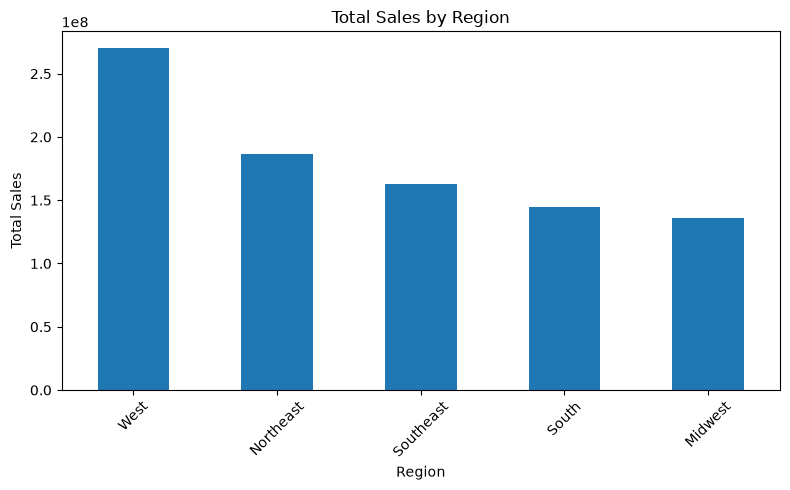

In [10]:
sales_region = df.groupby("Region")["Total Sales"].sum().sort_values(ascending=False)
sales_region.plot(kind="bar", figsize=(8, 5))
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 9. Profit by Product — Bar Chart

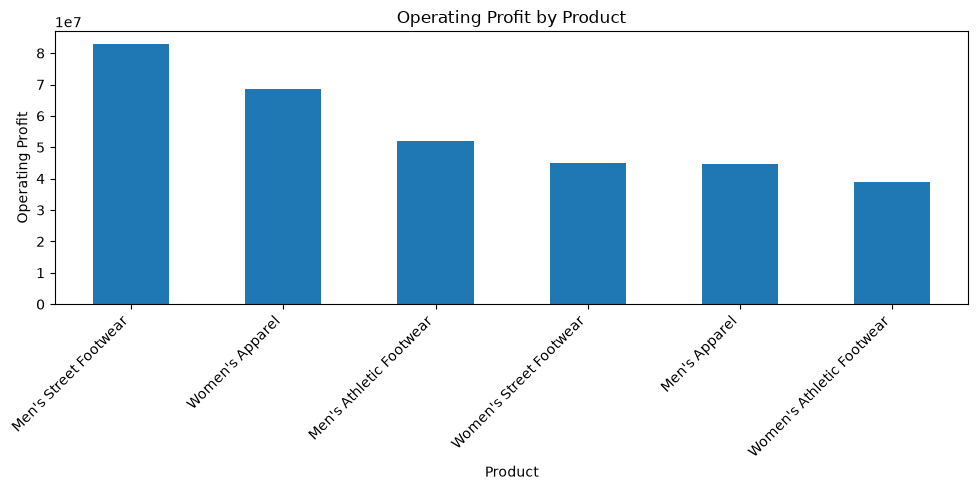

In [11]:
profit_product = df.groupby("Product")["Operating Profit"].sum().sort_values(ascending=False)
profit_product.plot(kind="bar", figsize=(10, 5))
plt.title("Operating Profit by Product")
plt.xlabel("Product")
plt.ylabel("Operating Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 10. Sales Histogram

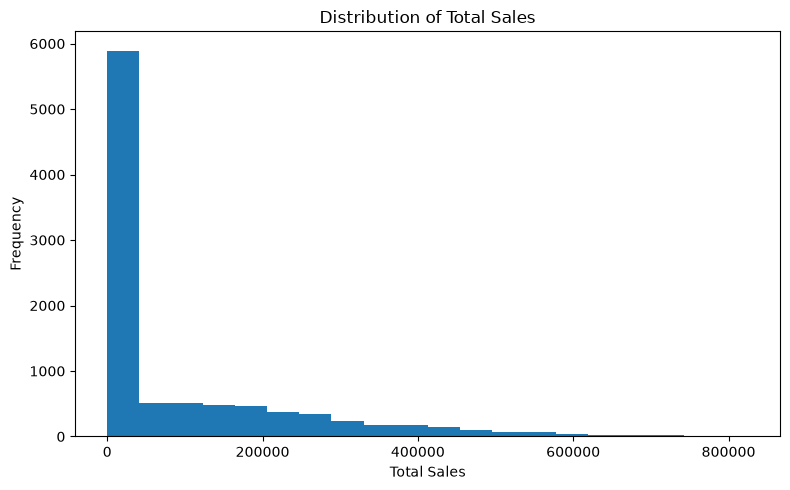

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["Total Sales"].dropna(), bins=20)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 11. Profit Histogram

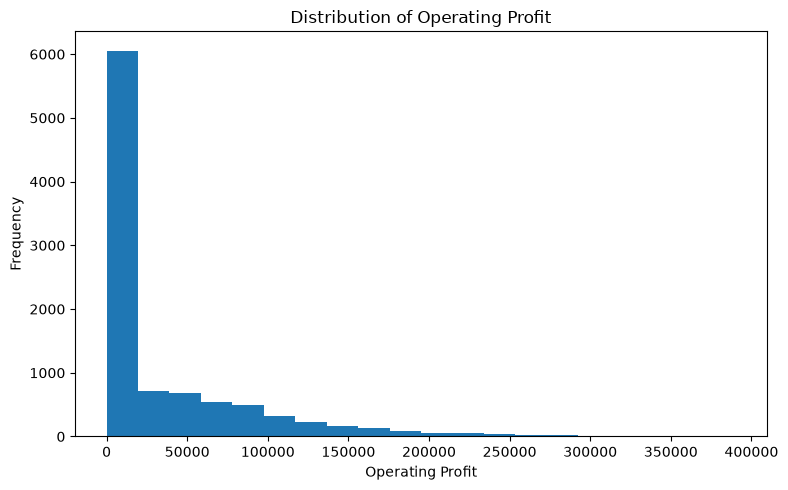

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df["Operating Profit"].dropna(), bins=20)
plt.title("Distribution of Operating Profit")
plt.xlabel("Operating Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 12. Sales Box Plot

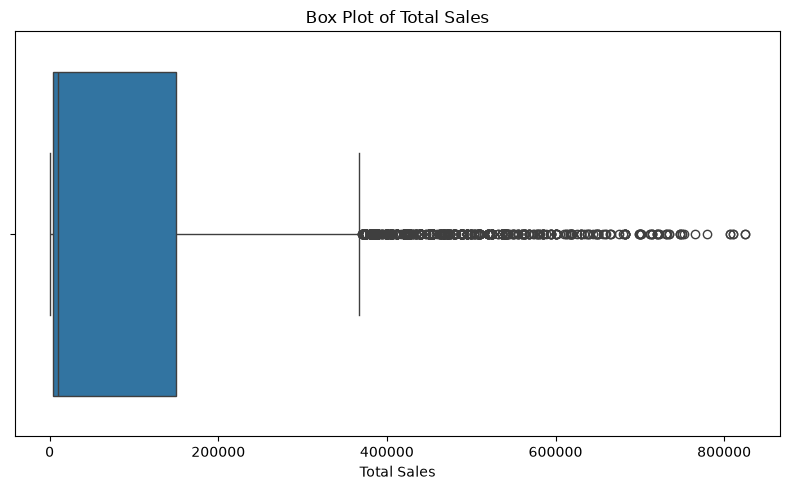

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Total Sales"])
plt.title("Box Plot of Total Sales")
plt.tight_layout()
plt.show()


## 13. Sales Method Pie Chart

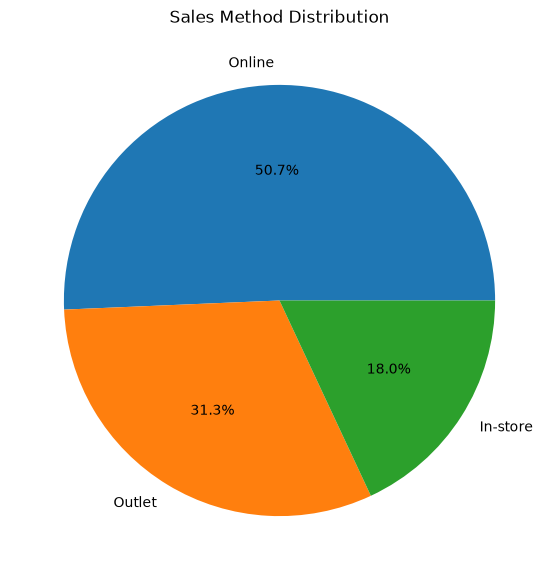

In [15]:
sales_method = df["Sales Method"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(sales_method, labels=sales_method.index, autopct="%1.1f%%")
plt.title("Sales Method Distribution")
plt.show()


## 14. Sales vs Profit Scatter Plot

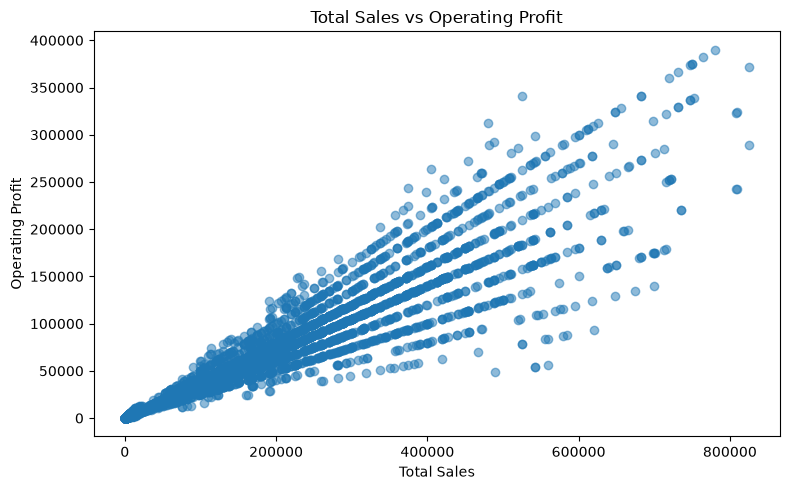

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Total Sales"], df["Operating Profit"], alpha=0.5)
plt.title("Total Sales vs Operating Profit")
plt.xlabel("Total Sales")
plt.ylabel("Operating Profit")
plt.tight_layout()
plt.show()


## 15. Correlation and Heatmap

,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
Price per Unit,1.000000,0.265869,0.435811,0.394546,-0.137486
Units Sold,0.265869,1.000000,0.913431,0.892379,-0.305479
Total Sales,0.435811,0.913431,1.000000,0.956307,-0.364592
Operating Profit,0.394546,0.892379,0.956307,1.000000,-0.211920
Operating Margin,-0.137486,-0.305479,-0.364592,-0.211920,1.000000


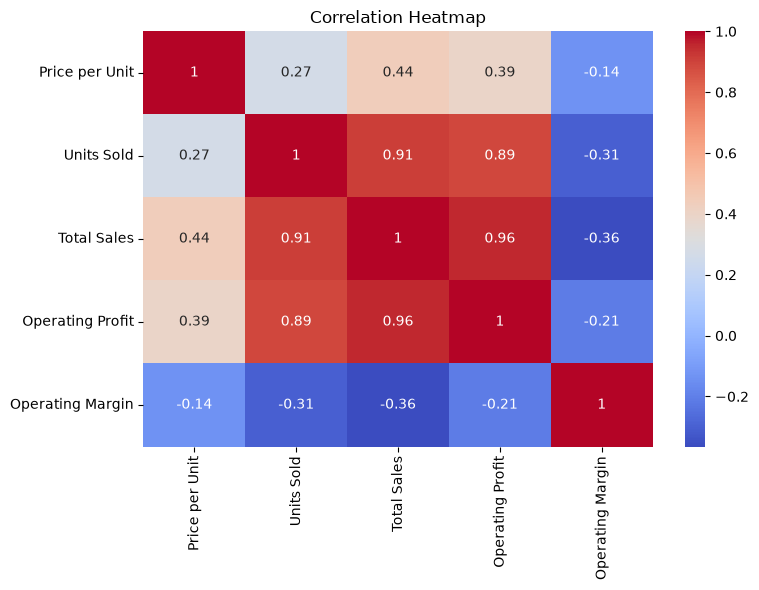

In [17]:
numeric_columns = ["Price per Unit", "Units Sold", "Total Sales", "Operating Profit", "Operating Margin"]
correlation = df[numeric_columns].corr()
display(correlation)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 16. Regression Analysis

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

regression_df = df[["Units Sold", "Total Sales"]].dropna()
X = regression_df[["Units Sold"]]
y = regression_df["Total Sales"]
model = LinearRegression()
model.fit(X, y)
prediction = model.predict(X)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R-squared:", r2_score(y, prediction))
print("MSE:", mean_squared_error(y, prediction))
print("RMSE:", np.sqrt(mean_squared_error(y, prediction)))


Coefficient: 605.0376983920339
Intercept: -62178.92092389878
R-squared: 0.8343570423610817
MSE: 3335729195.7039022
RMSE: 57755.77196872969


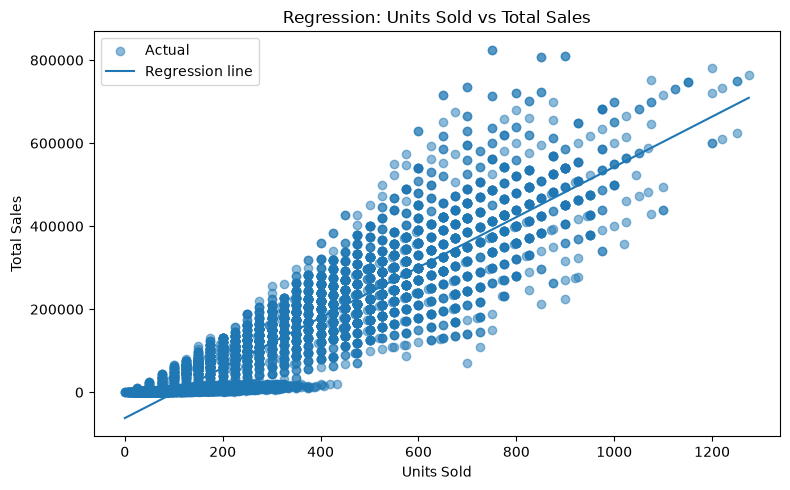

In [19]:
plot_df = regression_df.sort_values("Units Sold")
plt.figure(figsize=(8, 5))
plt.scatter(regression_df["Units Sold"], regression_df["Total Sales"], alpha=0.5, label="Actual")
plt.plot(plot_df["Units Sold"], model.predict(plot_df[["Units Sold"]]), label="Regression line")
plt.title("Regression: Units Sold vs Total Sales")
plt.xlabel("Units Sold")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()


## 17. Probability

In [20]:
total_records = len(df)
online_records = (df["Sales Method"].astype(str).str.lower() == "online").sum()
print("Probability of Online sales:", online_records / total_records if total_records else 0)

product = "Men's Street Footwear"
product_count = (df["Product"] == product).sum()
print("Probability of", product, ":", product_count / total_records if total_records else 0)


Probability of Online sales: 0.5067371475953566
Probability of Men's Street Footwear : 0.16687396351575456


## 18. Sampling and Central Limit Theorem

In [21]:
sample_sizes = [30, 50, 100]
sales = df["Total Sales"].dropna()
for size in sample_sizes:
    sample_means = []
    for _ in range(100):
        sample_means.append(sales.sample(size, replace=True).mean())
    print("Sample size:", size)
    print("Mean of sample means:", round(np.mean(sample_means), 2))
    print("Standard error:", round(np.std(sample_means, ddof=1), 2))


Sample size: 30
Mean of sample means: 84863.02
Standard error: 28271.86
Sample size: 50
Mean of sample means: 94825.9
Standard error: 21048.4
Sample size: 100
Mean of sample means: 92558.46
Standard error: 16072.1


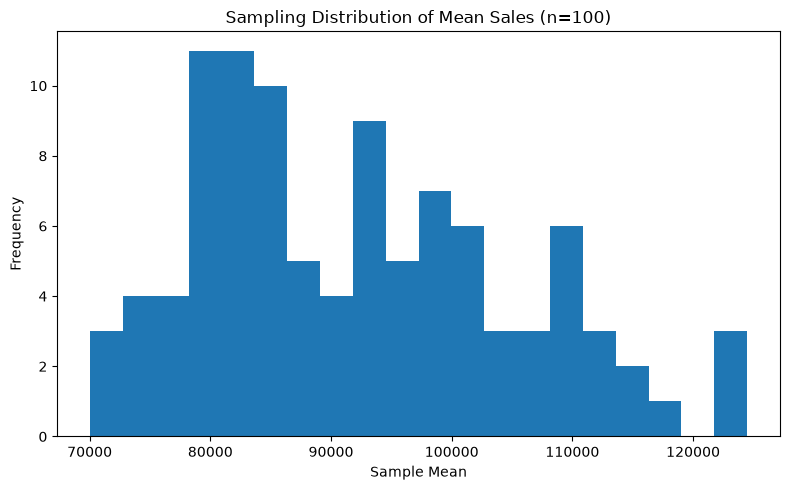

In [22]:
sales = df["Total Sales"].dropna()
sample_means = [sales.sample(100, replace=True).mean() for _ in range(100)]
plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=20)
plt.title("Sampling Distribution of Mean Sales (n=100)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 19. Confidence Interval (95%)

In [23]:
from scipy import stats
sales = df["Total Sales"].dropna()
mean = sales.mean()
n = len(sales)
standard_error = stats.sem(sales)
lower, upper = stats.t.interval(0.95, df=n-1, loc=mean, scale=standard_error)
print("Mean Total Sales:", round(mean, 2))
print("95% Confidence Interval:", (round(lower, 2), round(upper, 2)))


Mean Total Sales: 93273.44
95% Confidence Interval: (np.float64(90441.29), np.float64(96105.58))


## 20. Bootstrapping (1,000 Resamples)

Bootstrap mean: 93306.48
Bootstrap 95% confidence interval: (np.float64(90367.87), np.float64(96198.0))


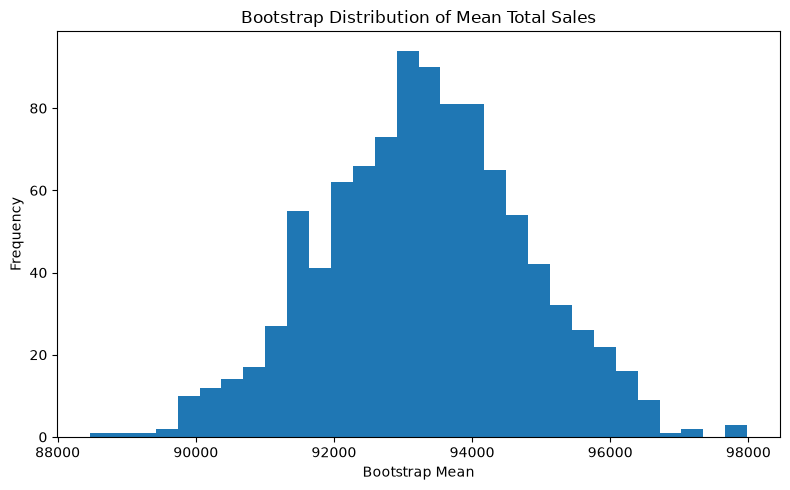

In [24]:
sales = df["Total Sales"].dropna().to_numpy()
bootstrap_means = []
for _ in range(1000):
    bootstrap_sample = np.random.choice(sales, size=len(sales), replace=True)
    bootstrap_means.append(bootstrap_sample.mean())
lower, upper = np.percentile(bootstrap_means, [2.5, 97.5])
print("Bootstrap mean:", round(np.mean(bootstrap_means), 2))
print("Bootstrap 95% confidence interval:", (round(lower, 2), round(upper, 2)))
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_means, bins=30)
plt.title("Bootstrap Distribution of Mean Total Sales")
plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 21. Hypothesis Testing

In [25]:
from scipy.stats import ttest_1samp
sales = df["Total Sales"].dropna()
result = ttest_1samp(sales, popmean=500000)
print("H0: Mean Total Sales = 500,000")
print("H1: Mean Total Sales is different from 500,000")
print("t-statistic:", result.statistic)
print("p-value:", result.pvalue)
print("Decision:", "Reject H0" if result.pvalue < 0.05 else "Fail to reject H0")


H0: Mean Total Sales = 500,000
H1: Mean Total Sales is different from 500,000
t-statistic: -281.50737084129156
p-value: 0.0
Decision: Reject H0


## 22. A/B Testing
The A/B dataset is synthetic for academic practice, not an observed Adidas marketing experiment.

In [26]:
ab = pd.read_csv("Adidas_AB_Testing_Dataset.csv")
display(ab.head())
display(ab.groupby("Variant")["Converted"].agg(["sum", "count", "mean"]))


,User_ID,Variant,Converted,Experiment,Data_Type,Note
0,AB-00001,B - Get 20% Off,0,Adidas Online Promotion A/B Test,Synthetic Academic Experiment,Created for academic A/B testing; not observed...
1,AB-00002,A - Shop Now,0,Adidas Online Promotion A/B Test,Synthetic Academic Experiment,Created for academic A/B testing; not observed...
2,AB-00003,B - Get 20% Off,0,Adidas Online Promotion A/B Test,Synthetic Academic Experiment,Created for academic A/B testing; not observed...
3,AB-00004,B - Get 20% Off,0,Adidas Online Promotion A/B Test,Synthetic Academic Experiment,Created for academic A/B testing; not observed...
4,AB-00005,A - Shop Now,0,Adidas Online Promotion A/B Test,Synthetic Academic Experiment,Created for academic A/B testing; not observed...


,sum,count,mean
Variant,,,
A - Shop Now,205,2023,0.101335
B - Get 20% Off,241,1977,0.121902


In [27]:
from statsmodels.stats.proportion import proportions_ztest
summary = ab.groupby("Variant")["Converted"].agg(["sum", "count"])
z_stat, p_value = proportions_ztest(summary["sum"].to_numpy(), summary["count"].to_numpy())
print("Z-statistic:", z_stat)
print("P-value:", p_value)
print("Decision:", "Significant difference" if p_value < 0.05 else "No significant difference detected")


Z-statistic: -2.066239808653719
P-value: 0.03880584171484606
Decision: Significant difference


## 23. Monthly Sales / Time Series

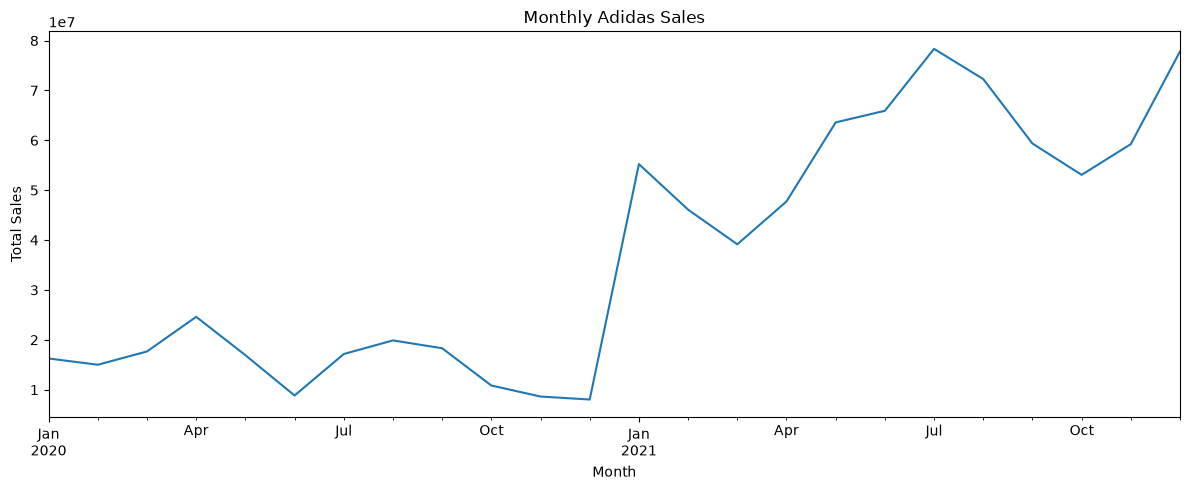

In [28]:
df["Invoice Date"] = pd.to_datetime(df["Invoice Date"], errors="coerce")
dated_df = df.dropna(subset=["Invoice Date"]).copy()
monthly_sales = dated_df.groupby(dated_df["Invoice Date"].dt.to_period("M"))["Total Sales"].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales.plot(figsize=(12, 5))
plt.title("Monthly Adidas Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


## 24. Moving Average

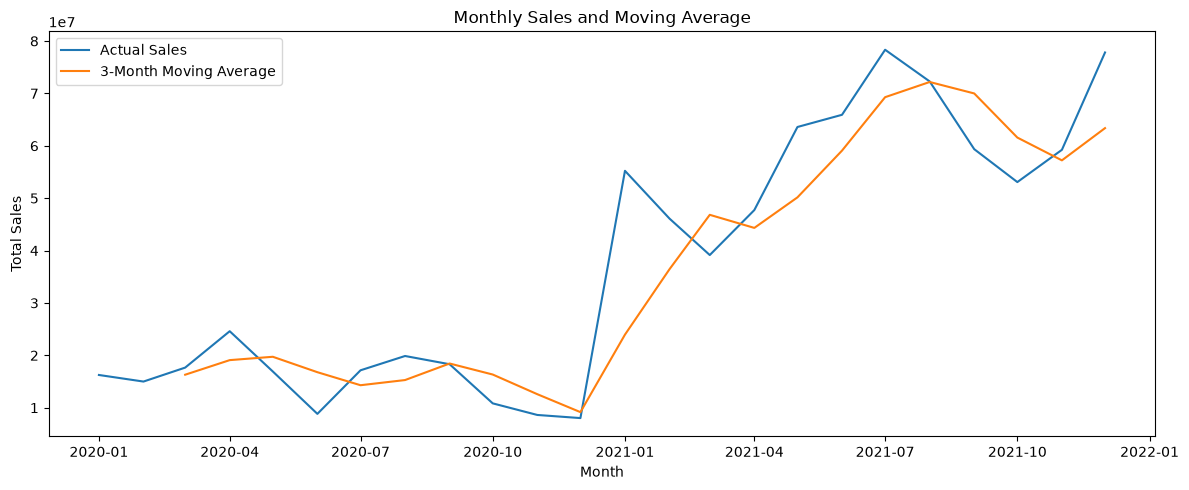

In [29]:
moving_average = monthly_sales.rolling(window=3).mean()
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, label="Actual Sales")
plt.plot(moving_average.index, moving_average.values, label="3-Month Moving Average")
plt.title("Monthly Sales and Moving Average")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()


## 25. Simulation

In [30]:
simulation = pd.read_csv("Adidas_Simulation_Dataset.csv")
print("Available columns:", simulation.columns.tolist())
display(simulation.head())


Available columns: ['Scenario', 'Simulation_Run', 'Demand_Units', 'Opening_Inventory', 'Selling_Price_INR', 'Unit_Cost_INR', 'Data_Type', 'Note']


,Scenario,Simulation_Run,Demand_Units,Opening_Inventory,Selling_Price_INR,Unit_Cost_INR,Data_Type,Note
0,Low Demand,1,610.91,1400,500,250,Synthetic Academic Simulation,Demand values are simulated for inventory/dema...
1,Low Demand,2,858.80,1400,500,250,Synthetic Academic Simulation,Demand values are simulated for inventory/dema...
2,Low Demand,3,817.15,1400,500,250,Synthetic Academic Simulation,Demand values are simulated for inventory/dema...
3,Low Demand,4,856.57,1400,500,250,Synthetic Academic Simulation,Demand values are simulated for inventory/dema...
4,Low Demand,5,870.74,1400,500,250,Synthetic Academic Simulation,Demand values are simulated for inventory/dema...


In [31]:
if "Scenario" in simulation.columns:
    numeric_cols = simulation.select_dtypes(include="number").columns.tolist()
    display(simulation.groupby("Scenario")[numeric_cols].mean())
else:
    print("No Scenario column found. Check the available column names above.")


,Simulation_Run,Demand_Units,Opening_Inventory,Selling_Price_INR,Unit_Cost_INR
Scenario,,,,,
High Demand,500.5,1593.88060,1400.0,500.0,250.0
Low Demand,500.5,803.76841,1400.0,500.0,250.0
Normal Demand,500.5,1193.30058,1400.0,500.0,250.0


## 26. ANOVA

In [32]:
from scipy.stats import f_oneway
groups = []
group_names = []
for name, group in df.groupby("Sales Method"):
    values = group["Operating Profit"].dropna()
    if len(values) > 1:
        groups.append(values)
        group_names.append(name)
print("Groups tested:", group_names)
if len(groups) >= 2:
    f_stat, p_value = f_oneway(*groups)
    print("F-statistic:", f_stat)
    print("P-value:", p_value)
    print("Decision:", "Significant difference" if p_value < 0.05 else "No significant difference detected")
else:
    print("At least two groups are required.")


Groups tested: ['In-store', 'Online', 'Outlet']
F-statistic: 722.5505092586285
P-value: 3.945070845824396e-293
Decision: Significant difference


## 27. Factorial Experiment

In [33]:
factorial = pd.read_csv("Adidas_Factorial_Experiment_Dataset.csv")
print("Available columns:", factorial.columns.tolist())
display(factorial.head())


Available columns: ['Experiment_ID', 'Sales_Method', 'Sales_Volume_Group', 'Operating_Profit_INR', 'Data_Type', 'Note']


,Experiment_ID,Sales_Method,Sales_Volume_Group,Operating_Profit_INR,Data_Type,Note
0,1,Online,Low Volume,146542.87,Synthetic Academic Factorial Experiment,Synthetic observations created to demonstrate ...
1,2,Online,Low Volume,144734.28,Synthetic Academic Factorial Experiment,Synthetic observations created to demonstrate ...
2,3,Online,Low Volume,137559.66,Synthetic Academic Factorial Experiment,Synthetic observations created to demonstrate ...
3,4,Online,Low Volume,153990.83,Synthetic Academic Factorial Experiment,Synthetic observations created to demonstrate ...
4,5,Online,Low Volume,155518.01,Synthetic Academic Factorial Experiment,Synthetic observations created to demonstrate ...


Sales_Volume_Group,High Volume,Low Volume,Medium Volume
Sales_Method,,,
In-store,223128.771000,149406.938500,184189.5405
Online,246527.528833,151552.674833,188398.5375


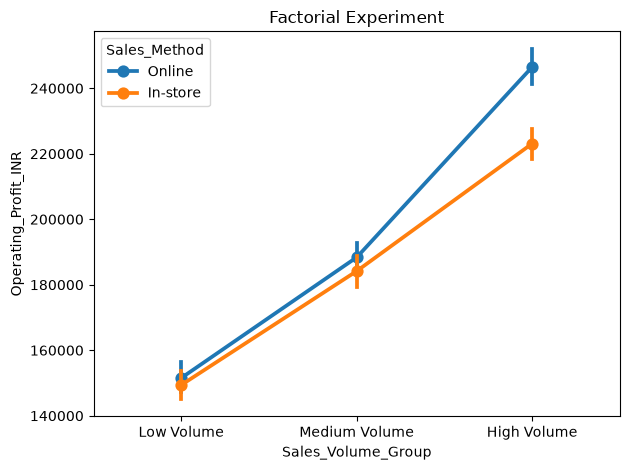

In [34]:
if {"Sales_Method", "Sales_Volume_Group", "Operating_Profit_INR"}.issubset(factorial.columns):
    display(factorial.groupby(["Sales_Method", "Sales_Volume_Group"])["Operating_Profit_INR"].mean().unstack())
    sns.pointplot(data=factorial, x="Sales_Volume_Group", y="Operating_Profit_INR", hue="Sales_Method")
    plt.title("Factorial Experiment")
    plt.tight_layout()
    plt.show()
else:
    print("Expected columns not found; check the column list in the previous cell.")


## 28. Decision Making / Expected Value

In [35]:
decision = pd.read_csv("Adidas_Decision_Making_Dataset.csv")
print("Available columns:", decision.columns.tolist())
display(decision.head())


Available columns: ['Alternative', 'Outcome', 'Probability', 'Payoff_INR', 'Expected_Value_Component_INR', 'Data_Type', 'Note']


,Alternative,Outcome,Probability,Payoff_INR,Expected_Value_Component_INR,Data_Type,Note
0,Standard Promotion,High Demand,0.4,500000,200000.0,Synthetic Academic Decision Scenario,Probabilities and payoffs are academic assumpt...
1,Standard Promotion,Medium Demand,0.4,300000,120000.0,Synthetic Academic Decision Scenario,Probabilities and payoffs are academic assumpt...
2,Standard Promotion,Low Demand,0.2,100000,20000.0,Synthetic Academic Decision Scenario,Probabilities and payoffs are academic assumpt...
3,High Discount Promotion,High Demand,0.4,560000,224000.0,Synthetic Academic Decision Scenario,Probabilities and payoffs are academic assumpt...
4,High Discount Promotion,Medium Demand,0.4,280000,112000.0,Synthetic Academic Decision Scenario,Probabilities and payoffs are academic assumpt...


In [36]:
if {"Alternative", "Probability", "Payoff_INR"}.issubset(decision.columns):
    decision["Expected_Value_Component"] = decision["Probability"] * decision["Payoff_INR"]
    values = decision.groupby("Alternative")["Expected_Value_Component"].sum().sort_values(ascending=False)
    display(values)
    print("Best alternative:", values.idxmax())
    print("Expected value:", values.max())
else:
    print("Expected columns not found; check the column list above.")


Alternative
High Discount Promotion    352000.0
Premium Promotion          346000.0
Standard Promotion         340000.0
Name: Expected_Value_Component, dtype: float64

Best alternative: High Discount Promotion
Expected value: 352000.0


## 29. Optimization Input Dataset

In [37]:
optimization = pd.read_csv("Adidas_Optimization_Input_Dataset.csv")
display(optimization.head())
if "Product" in optimization.columns:
    print("Products:", optimization["Product"].tolist())


,Product,Avg_Profit_Per_Unit,Avg_Sales_Per_Unit,Avg_Units_Sold,Machine_Hours_Per_Unit,Labor_Hours_Per_Unit,Budget_Per_Unit_INR,Data_Type,Note
0,Men's Apparel,90.035137,247.330012,190.960772,1,1,136.031507,Master-derived product statistics + modeled re...,Profit/sales statistics come from the master d...
1,Men's Athletic Footwear,75.226441,214.751553,270.513043,1,1,118.113354,Master-derived product statistics + modeled re...,Profit/sales statistics come from the master d...
2,Men's Street Footwear,86.908801,218.059627,368.521739,3,2,119.932795,Master-derived product statistics + modeled re...,Profit/sales statistics come from the master d...
3,Women's Apparel,97.779813,253.569030,269.792910,3,3,139.462966,Master-derived product statistics + modeled re...,Profit/sales statistics come from the master d...
4,Women's Athletic Footwear,74.472091,200.856429,197.531756,2,1,110.471036,Master-derived product statistics + modeled re...,Profit/sales statistics come from the master d...


Products: ["Men's Apparel", "Men's Athletic Footwear", "Men's Street Footwear", "Women's Apparel", "Women's Athletic Footwear", "Women's Street Footwear"]


## 30. Final Business Summary

In [38]:
print("ADIDAS BUSINESS ANALYTICS SUMMARY")
print("---------------------------------")
print("Total Sales:", round(df["Total Sales"].sum(), 2))
print("Total Operating Profit:", round(df["Operating Profit"].sum(), 2))
print("Total Units Sold:", round(df["Units Sold"].sum(), 2))
print("Average Operating Margin:", round(df["Operating Margin"].mean(), 2))
if "Customer ID" in df.columns:
    print("Unique Customers:", df["Customer ID"].nunique())


ADIDAS BUSINESS ANALYTICS SUMMARY
---------------------------------
Total Sales: 899902125
Total Operating Profit: 332134761.45
Total Units Sold: 2478861
Average Operating Margin: 0.42
Unique Customers: 2368
